In [17]:
import numpy as np
import serial
import time
import matplotlib.pyplot as plt
from IPython import display
import concurrent.futures
import serial.tools.list_ports
ports = serial.tools.list_ports.comports()
ambit_ports = [x[0] for x in ports if "CH9102" in x[1]]
print("Available ports:", ambit_ports)

Available ports: ['COM31', 'COM35']


In [18]:
def ser_readline(ser: serial.Serial, timeout = .5, get_all_lines = False):
    t0 = time.perf_counter()
    _str = ''
    bad_counter = 0
    lines = []
    while time.perf_counter() - t0 < timeout:
        if ser.in_waiting == 0:
            time.sleep(.1)
            continue
        c = ser.read()
        if (c == bytes([0])) or (c > bytes([127])):
            bad_counter += 1
            continue

        _str += c.decode()
        if (c == b"\n") or (c == b"\r"):
            _line = _str
            _str = ''
            if get_all_lines:
                t0 = time.perf_counter()
                lines.append(_line)
            else:
                return [_line]
        if bad_counter > 50:
            print("hex")
            break
    return lines


def parse_data(ret1:str)->np.ndarray:
    data = [[], [], [], [], [], []]
    for _l in ret1:
        if not _l.startswith("T:"): continue
        _s = _l.split(',')
        if len(_s) != 6: continue
        for n in range(6):
            _s2 = _s[n].split(':')
            if len(_s2) != 2: continue
            if _s2[0] == ["T", "F", "S", "R", "Sun", "L"][n]: data[n].append(float(_s2[1]))
    return np.array(data)

#helper functions
# convert protocol to ambit array
def gen_cmd_arr_line(num:int, freq:int, actinic:int)->list:
    return [2, 0, num//256, num%256, freq//256, freq%256, actinic, 1]


# flatten ambit array, calc time, actinic array
def calc_arr_param(cmd: list, persist:bool = False):
    cmd_arr = np.reshape(cmd, (-1, 8))
    arr_length = cmd_arr.shape[0]
    cmd_str = "arrun1," + str(arr_length) + "," + str(persist) + ","+ str(cmd)[1:-1] + ",\n"
    cmd_str = cmd_str.replace(" ", "")

    num_pts = cmd_arr[:, 2] * 256 + cmd_arr[:, 3]
    act_arr = cmd_arr[:, 6]
    mea_feq = 1 / (cmd_arr[:, 4] * 256 + cmd_arr[:, 5])
    _t, mea_tml, mea_act = 0, [], []
    for _n, _f, _a in zip(num_pts, mea_feq, act_arr):
        mea_tml += (np.arange(_n) * _f + _t).tolist()
        mea_act += [_a] * _n
        _t = mea_tml[-1]
    mea_tml = np.array(mea_tml) * 0.854
    return cmd_str, mea_tml, mea_act

In [19]:
def cmd2(cmd:str, ser1: serial.Serial, ser2: serial.Serial, timeout = .5, get_all_lines = False)-> (str, str):    
    with concurrent.futures.ThreadPoolExecutor(max_workers=2) as executor:
        ser1.write((cmd+'\n\r').encode())
        ser2.write((cmd+'\n\r').encode())
        f1 = executor.submit(ser_readline, ser1, timeout, get_all_lines)
        f2 = executor.submit(ser_readline, ser2, timeout, get_all_lines)
        result1 = f1.result()
        result2 = f2.result()
        return result1, result2

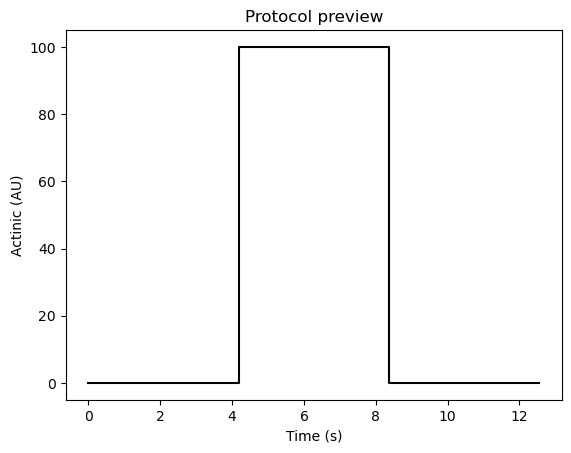

In [20]:
light_intensity_test_protocols = []
# create a trace with 3 different setups:
# 1. 50 points, 10Hz, no actinic
# 2. 50 points, 50Hz, 240/255(max) actinic
# 3. 50 points, 10Hz, no actinic
# number of lines (1 - 8) points(10 - 2000), freq (1 - 200), actinic 0 - 255

cmd = []
cmd += gen_cmd_arr_line(num = 50, freq = 10, actinic = 0)
cmd += gen_cmd_arr_line(num = 50, freq = 10, actinic = 100)
cmd += gen_cmd_arr_line(num = 50, freq = 10, actinic = 0)
wait_time = 1


# convert to command for ambit, also pre-calculate the time and actinic of each point
cmd_str, timeline, act_arr = calc_arr_param(cmd, 0)
plt.plot(timeline, act_arr, 'k')
plt.xlabel("Time (s)")
plt.ylabel("Actinic (AU)")
plt.title("Protocol preview")
light_intensity_test_protocols.append((cmd_str, timeline, act_arr, wait_time))

In [27]:
with serial.Serial(ambit_ports[0], baudrate=115200) as ser1:
    ser1.write(cmd_str.encode())
    time.sleep(1)

In [29]:
with serial.Serial(ambit_ports[0], baudrate=115200) as ser1:
    with serial.Serial(ambit_ports[1], baudrate=115200) as ser2:
        for cmd_str, timeline, act_arr, wt in light_intensity_test_protocols:
            ret1, ret2 = cmd2(cmd_str, ser1, ser2, wt, True)
            print(wt)


1


In [4]:
protocols = []

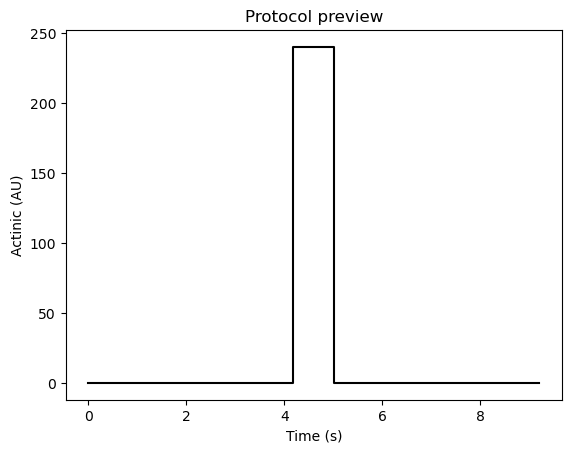

In [5]:
# create a trace with 3 different setups:
# 1. 50 points, 10Hz, no actinic
# 2. 50 points, 50Hz, 240/255(max) actinic
# 3. 50 points, 10Hz, no actinic
# number of lines (1 - 8) points(10 - 2000), freq (1 - 200), actinic 0 - 255

cmd = []
cmd += gen_cmd_arr_line(num = 50, freq = 10, actinic = 0)
cmd += gen_cmd_arr_line(num = 50, freq = 50, actinic = 240)
cmd += gen_cmd_arr_line(num = 50, freq = 10, actinic = 0)
wait_time = 1


# convert to command for ambit, also pre-calculate the time and actinic of each point
cmd_str, timeline, act_arr = calc_arr_param(cmd, 0)
plt.plot(timeline, act_arr, 'k')
plt.xlabel("Time (s)")
plt.ylabel("Actinic (AU)")
plt.title("Protocol preview")
protocols.append((cmd_str, timeline, act_arr, wait_time))

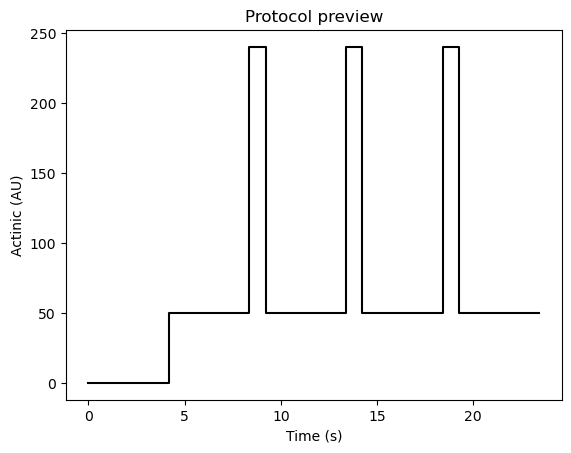

In [6]:
# create a trace with 3 different setups:
# 1. 50 points, 10Hz, no actinic
# 2. 50 points, 50Hz, 240/255(max) actinic
# 3. 50 points, 10Hz, no actinic
# number of lines (1 - 8) points(10 - 2000), freq (1 - 200), actinic 0 - 255

cmd = []
cmd += gen_cmd_arr_line(num = 50, freq = 10, actinic = 0)
cmd += gen_cmd_arr_line(num = 50, freq = 10, actinic = 50)
cmd += gen_cmd_arr_line(num = 50, freq = 50, actinic = 240)
cmd += gen_cmd_arr_line(num = 50, freq = 10, actinic = 50)
cmd += gen_cmd_arr_line(num = 50, freq = 50, actinic = 240)
cmd += gen_cmd_arr_line(num = 50, freq = 10, actinic = 50)
cmd += gen_cmd_arr_line(num = 50, freq = 50, actinic = 240)
cmd += gen_cmd_arr_line(num = 50, freq = 10, actinic = 50)

# convert to command for ambit, also pre-calculate the time and actinic of each point
cmd_str, timeline, act_arr = calc_arr_param(cmd, 0)
wait_time = 1

plt.plot(timeline, act_arr, 'k')
plt.xlabel("Time (s)")
plt.ylabel("Actinic (AU)")
plt.title("Protocol preview")


protocols.append((cmd_str, timeline, act_arr, wait_time))

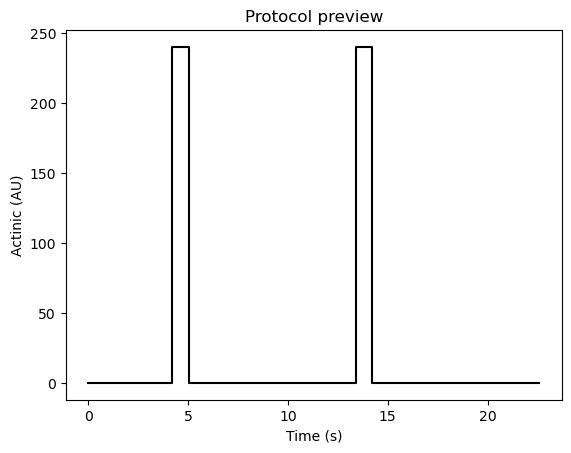

In [7]:
# create a trace with 3 different setups:
# 1. 50 points, 10Hz, no actinic
# 2. 50 points, 50Hz, 240/255(max) actinic
# 3. 50 points, 10Hz, no actinic
# number of lines (1 - 8) points(10 - 2000), freq (1 - 200), actinic 0 - 255

cmd = []
cmd += gen_cmd_arr_line(num = 50, freq = 10, actinic = 0)
cmd += gen_cmd_arr_line(num = 50, freq = 50, actinic = 240)
cmd += gen_cmd_arr_line(num = 50, freq = 5, actinic = 0)
cmd += gen_cmd_arr_line(num = 50, freq = 50, actinic = 240)
cmd += gen_cmd_arr_line(num = 50, freq = 5, actinic = 0)
# cmd += gen_cmd_arr_line(num = 50, freq = 50, actinic = 240)
# cmd += gen_cmd_arr_line(num = 50, freq = 1, actinic = 0)
# cmd += gen_cmd_arr_line(num = 50, freq = 50, actinic = 240)
# cmd += gen_cmd_arr_line(num = 10, freq = 1, actinic = 0)

# convert to command for ambit, also pre-calculate the time and actinic of each point
cmd_str, timeline, act_arr = calc_arr_param(cmd, 0)
wait_time = 10
plt.plot(timeline, act_arr, 'k')
plt.xlabel("Time (s)")
plt.ylabel("Actinic (AU)")
plt.title("Protocol preview")


protocols.append((cmd_str, timeline, act_arr, wait_time))

In [ ]:
_t0 = time.perf_counter()
with serial.Serial("COM3", baudrate=115200) as ser1:
    with serial.Serial("COM13", baudrate=115200) as ser2:
        data = []
        for cmd_str, timeline, act_arr, wt in protocols:
            _ts = time.perf_counter()
            ret1, ret2 = cmd2(cmd_str, ser1, ser2, wt, True)
            print(wt)
            data.append((_ts - _t0, [parse_data(ret1), parse_data(ret2)], timeline, act_arr))


1
1


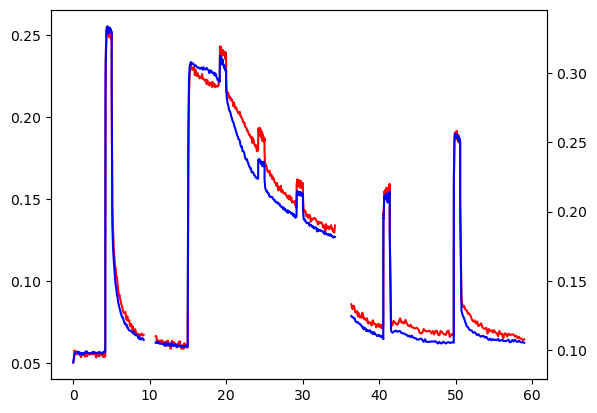

In [ ]:
# norm1 = lambda x:  (x - x[10:40].mean()) / (x[60:90].mean() - x[10:40].mean())

_, axis = plt.subplots(1, 1)
ax2 = axis.twinx()
for t0, fluos, tl, arr in data:
    f1 = fluos[0][2,:]/fluos[0][3,:]
    f2 = fluos[1][2,:]/fluos[1][3,:]
    axis.plot(tl + t0, f1, 'r')
    ax2.plot(tl + t0, f2, 'b')

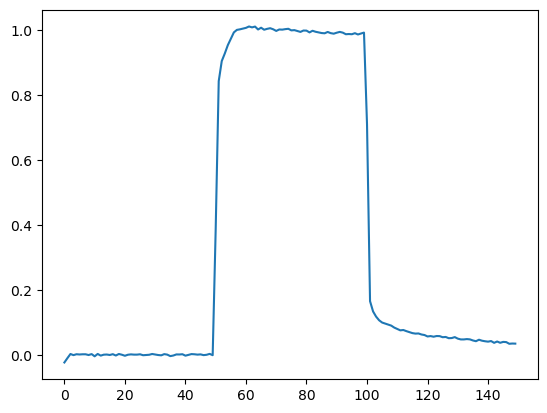

In [ ]:
norm = lambda x:  (x - x[10:40].mean()) / (x[60:90].mean() - x[10:40].mean())

plt.plot(norm(data[0][1][0][1,:]))


In [ ]:
# Save the experiment data to a CSV file
import pandas as pd
from datetime import datetime

# Customize the title of the experiment file
title = "experiment_dual_sensor"

# Generate timestamp to avoid overwriting
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Flatten all protocol data into rows
all_rows = []
for i, (t0, fluos, tl, act) in enumerate(data):
    f1 = fluos[0][2, :] / fluos[0][3, :]
    f2 = fluos[1][2, :] / fluos[1][3, :]
    for t, a, val1, val2 in zip(tl + t0, act, f1, f2):
        all_rows.append({
            "protocol_index": i,
            "time": t,
            "actinic": a,
            "sensor1_ratio": val1,
            "sensor2_ratio": val2
        })

# Convert to DataFrame and save to CSV
df = pd.DataFrame(all_rows)
filename = f"{title}_{timestamp}.csv"
df.to_csv(filename, index=False)

print(f"✅ Data saved to: {filename}")


In [ ]:
# 📦 Save experimental data along with metadata
import pandas as pd
import json
from datetime import datetime

# ✏️ Fill in your experiment metadata here
metadata = {
    "genotype": "mutant1",                    # e.g., WT, mutant1, mutant2
    "temperature_sensor2": "30C",            # oC
    "sensor1_condition": "room_temp",         # always fixed
    "sensor2_condition": "variable_temp",     # actual experiment
    "date": datetime.now().strftime("%Y-%m-%d"),
    "timestamp": datetime.now().strftime("%Y%m%d_%H%M%S")
}

# 📁 Create file name based on genotype and temperature
title = f"{metadata['genotype']}_{metadata['temperature_sensor2']}_{metadata['timestamp']}"

# 🧪 Flatten your collected `data` list into a structured table
all_rows = []
for i, (t0, fluos, tl, act) in enumerate(data):
    f1 = fluos[0][2, :] / fluos[0][3, :]
    f2 = fluos[1][2, :] / fluos[1][3, :]
    for t, a, val1, val2 in zip(tl + t0, act, f1, f2):
        all_rows.append({
            "protocol_index": i,
            "time": t,
            "actinic": a,
            "sensor1_ratio": val1,
            "sensor2_ratio": val2
        })

# 📊 Save the data as CSV
df = pd.DataFrame(all_rows)
df.to_csv(f"{title}.csv", index=False)

# 📝 Save the metadata as JSON
with open(f"{title}_meta.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)

print(f"✅ Saved: {title}.csv and {title}_meta.json")